In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig5_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff')

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:214: RuntimeWarning: Mean of empty slice
  comb = np.nanmean(np.concatenate((data['baseline_act'], data['block_act'])),axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:215: RuntimeWarning: Mean of empty slice
  fam = np.nanmean(data['block_fam_act'], axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:216: RuntimeWarning: Mean of empty slice
  nov = np.nanmean(data['block_nov_act'], axis=-1)/base.mean()


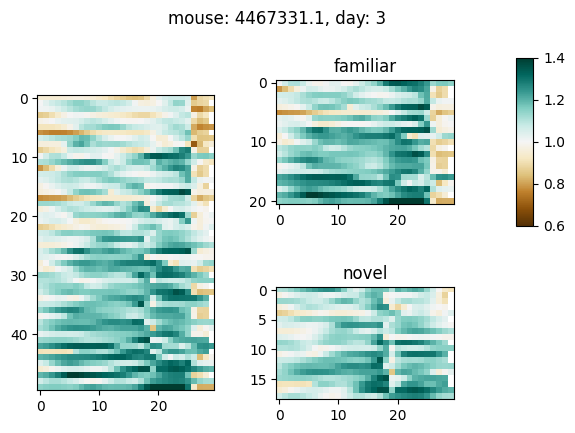

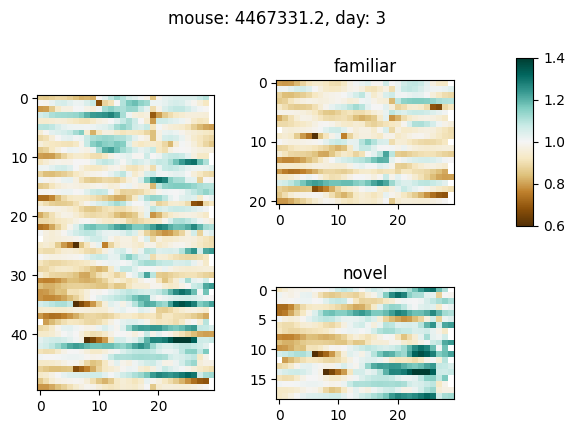

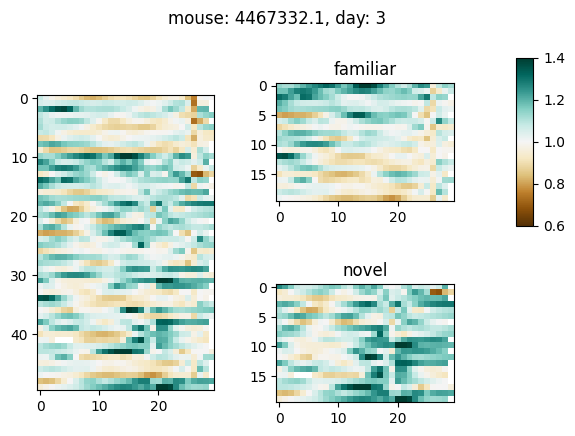

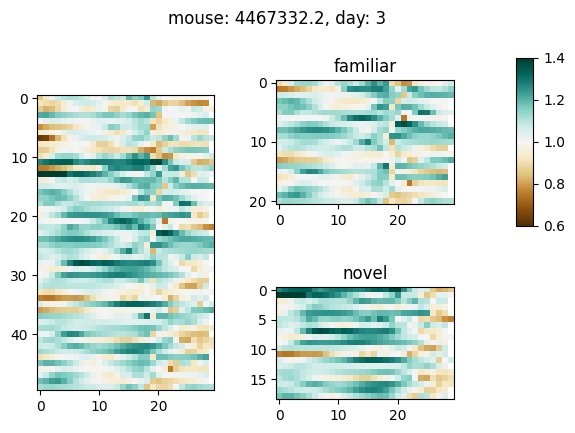

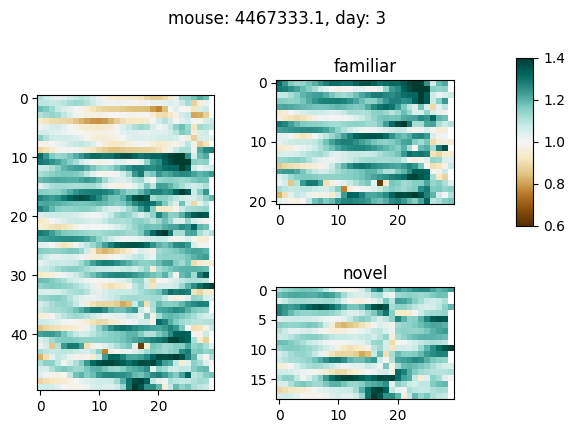

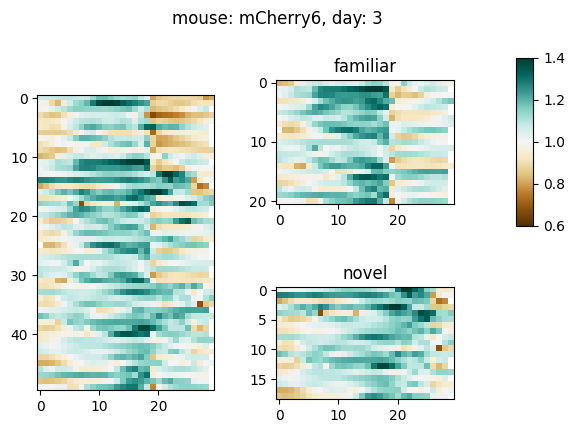

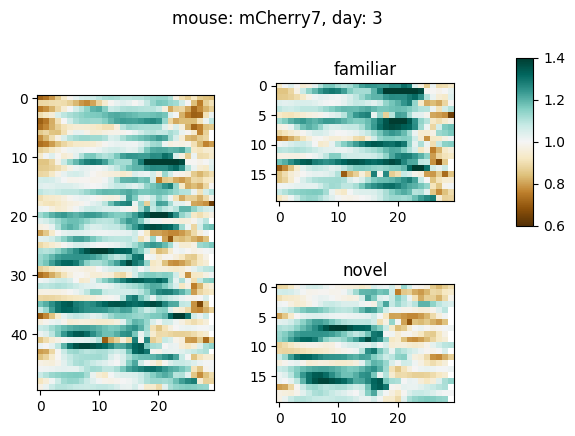

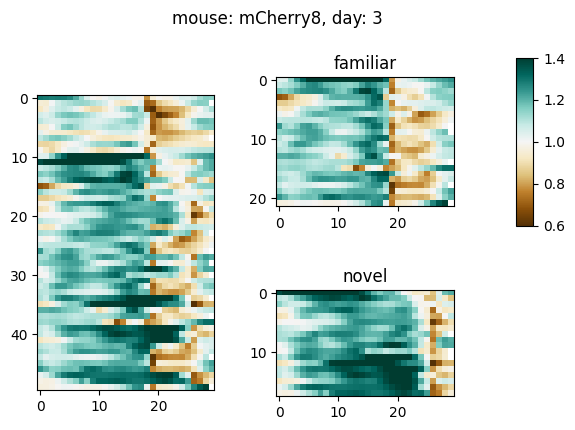

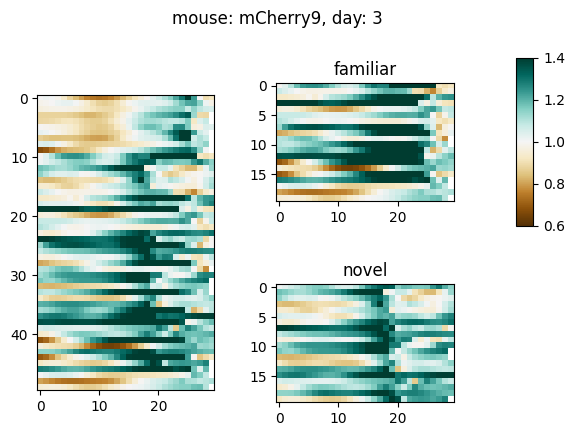

In [33]:
subdir =  figdir / 'single_sessions'
subdir.mkdir(exist_ok=True, parents=True)
for mouse in ctrl_mice:
    fig, ax = block_rate.plot_single_session('ctrl', mouse, 3, norm='population', cmap='BrBG', vmin=.6, vmax=1.4)

    fig.savefig(subdir / f'ctrl_{mouse}_day3_activity_rate.pdf')

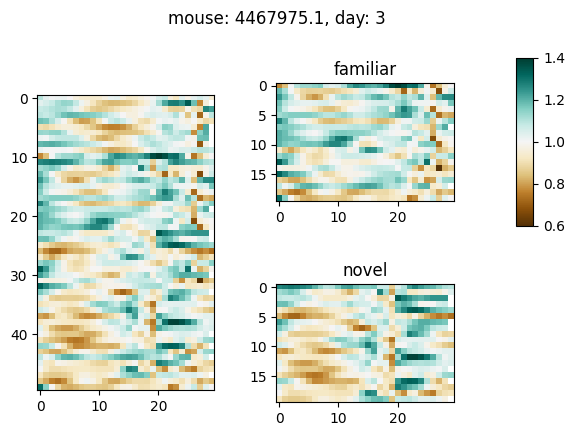

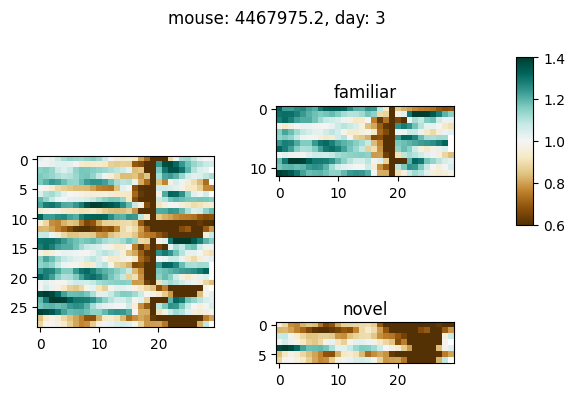

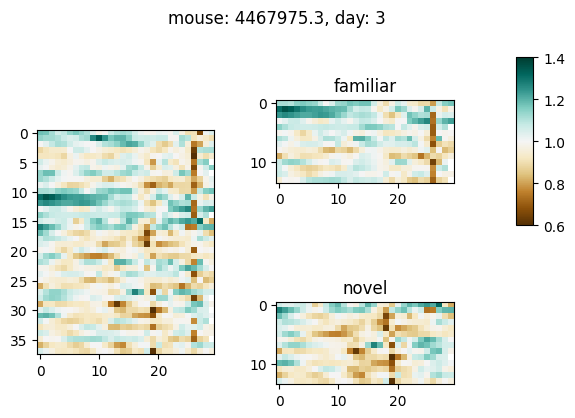

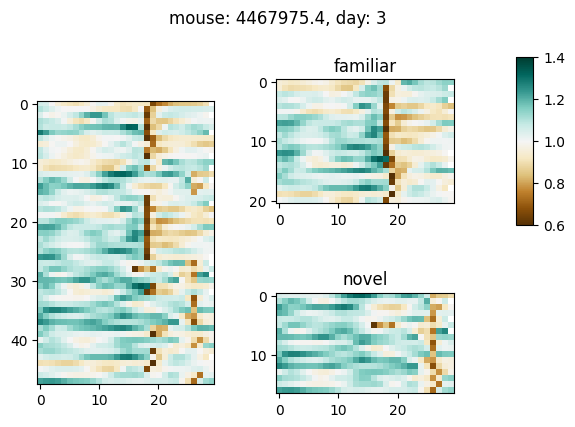

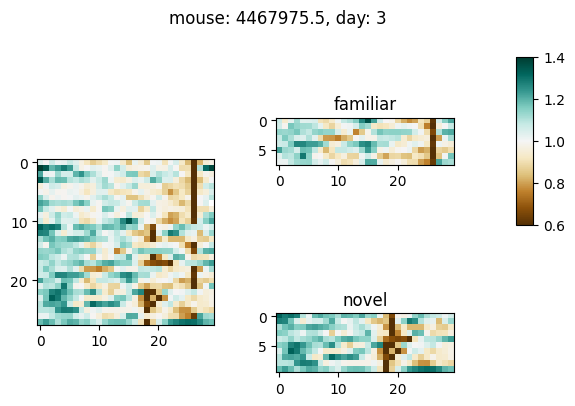

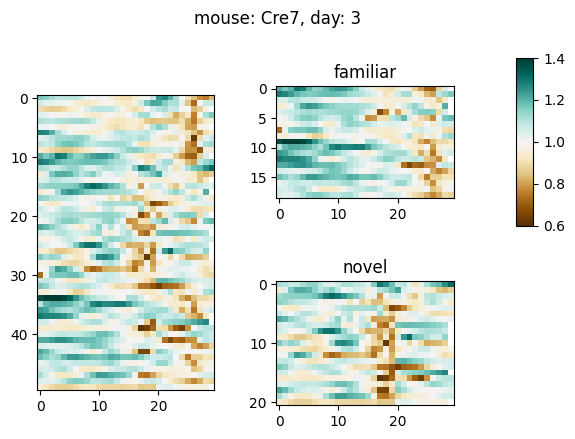

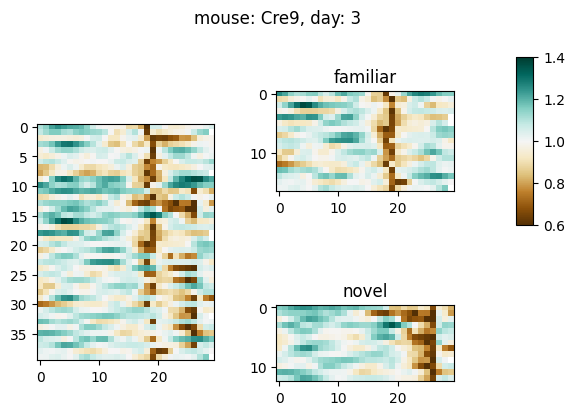

In [34]:
for mouse in ko_mice:
    fig, ax = block_rate.plot_single_session('ko', mouse, 3, norm='population', cmap='BrBG', vmin=.6, vmax=1.4)

    fig.savefig(subdir / f'ko_{mouse}_day3_activity_rate.pdf')

plot average activity, running speed and licks with no normalization

plot population normalized activity, speed and licks

linear model with activity or normalized activity

In [6]:
def plot_block_avg(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
        fam = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}
        nov = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}

        for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
            for i, mouse in enumerate(mice):
                data = block_rate.activity_rates[cond][mouse][day]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base
                    fam[cond][i,:_fam.shape[0]] = _fam
                    nov[cond][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base/_base.mean()
                    fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[cond][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[cond][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[cond][i,:_nov.shape[0]] = _nov

        for cond, color in zip(('ctrl','ko'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        a.set_xlabel('Trial')
    return fig, ax

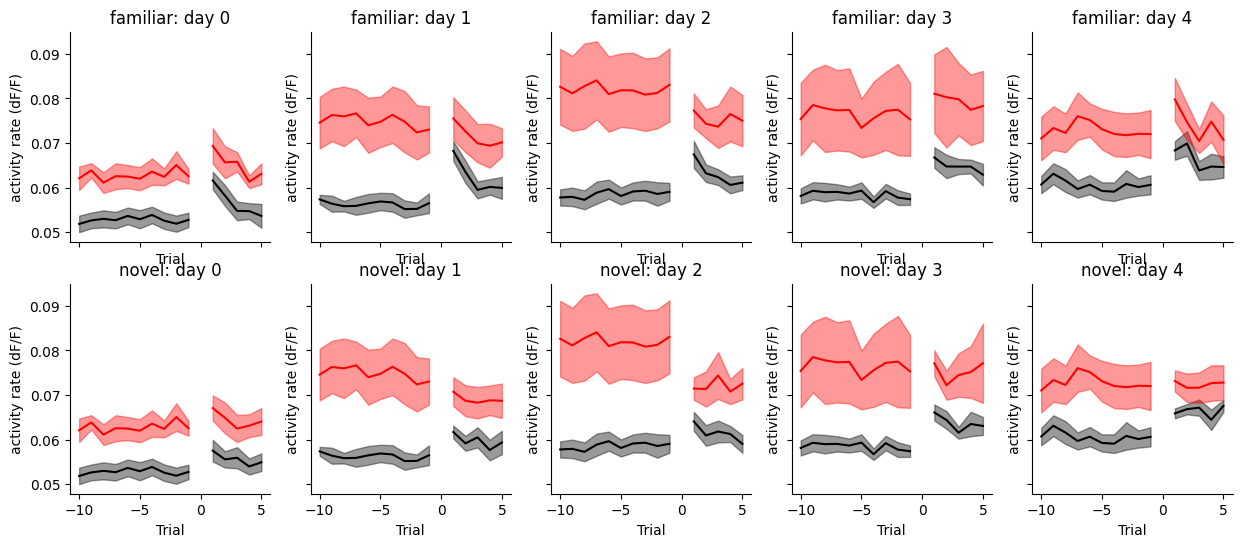

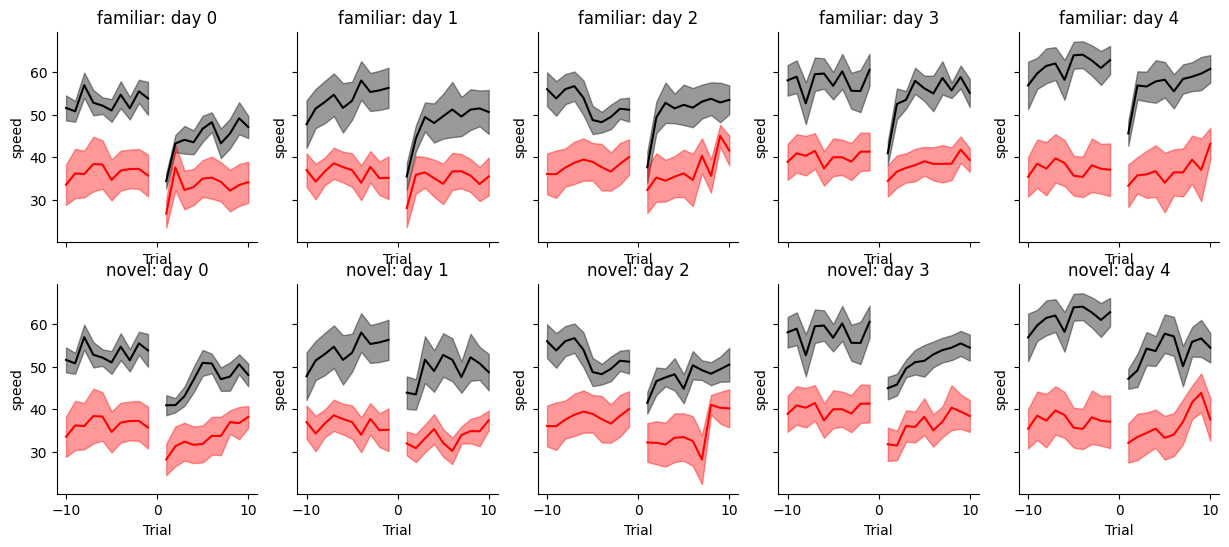

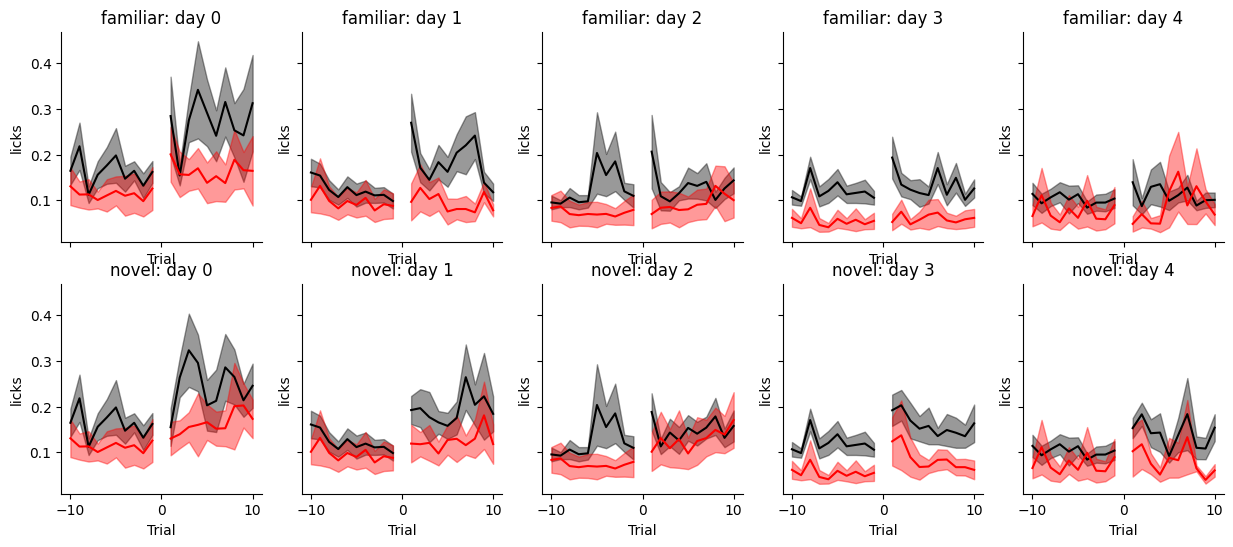

In [35]:
fig, ax = plot_block_avg(block_rate, norm = None, max_trial=5)
fig.savefig(figdir / 'last_block_activity_rate.pdf')
fig, ax = plot_block_avg(block_rate, key='speed', norm = None, max_trial=10)
fig, ax = plot_block_avg(block_rate, key='licks', norm = None, max_trial=10)

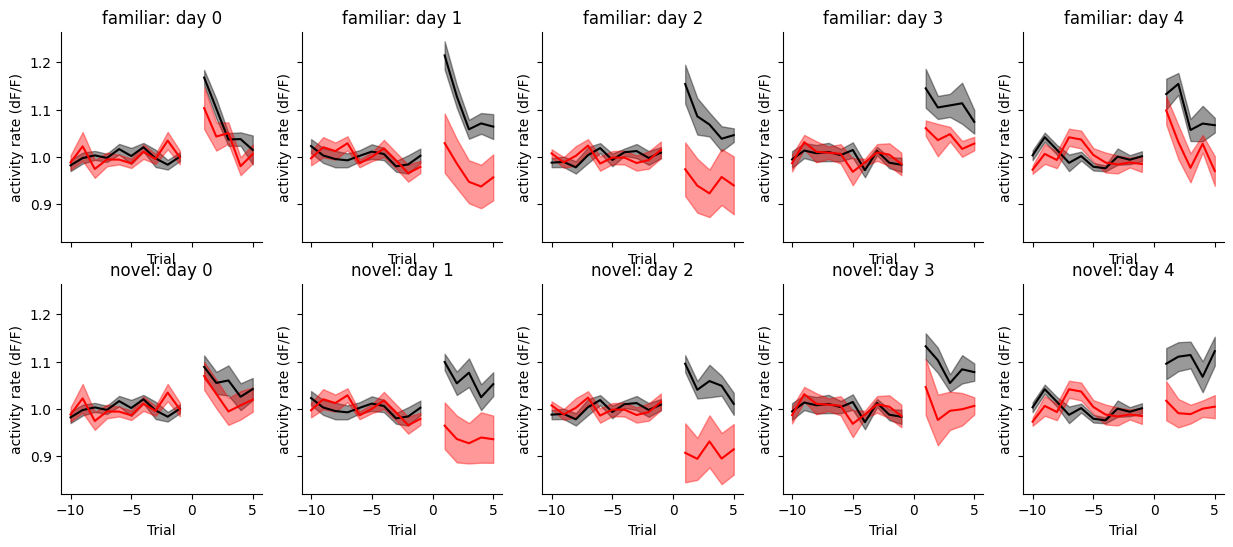

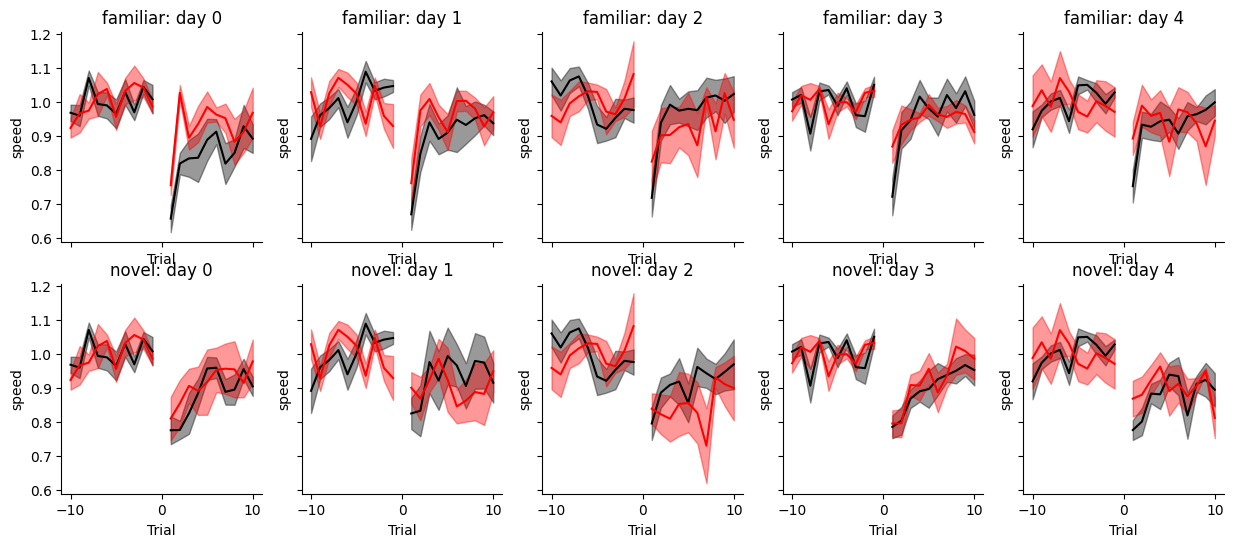

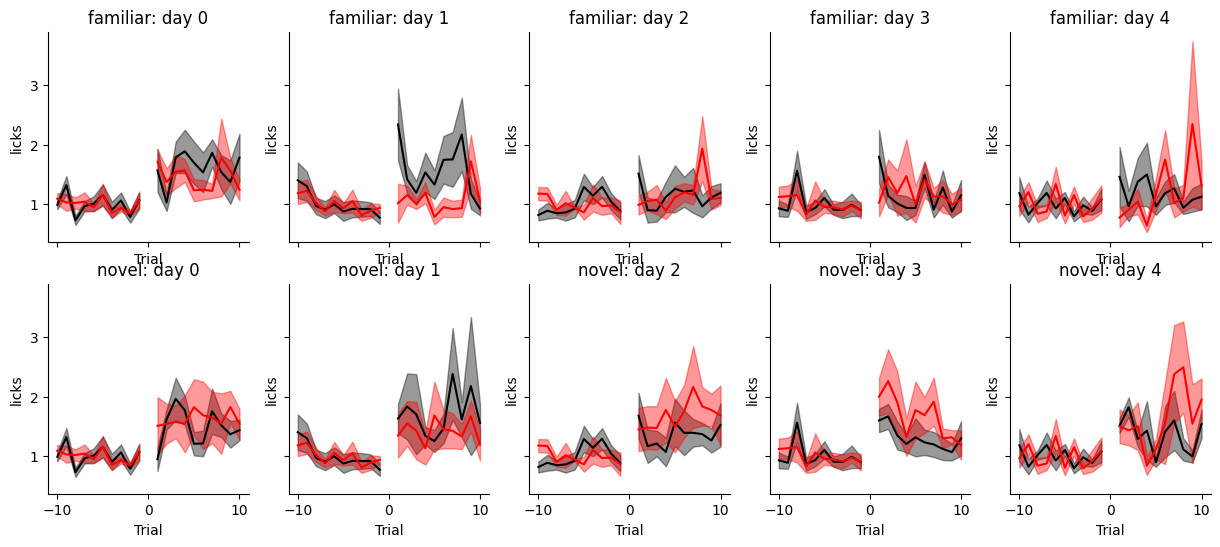

In [36]:
fig, ax = plot_block_avg(block_rate, norm = 'population', max_trial=5)
fig.savefig(figdir / 'last_block_activity_rate_population_norm.pdf')
fig, ax = plot_block_avg(block_rate, key='speed', norm = 'population', max_trial=10)
fig, ax = plot_block_avg(block_rate, key='licks', norm = 'population', max_trial=10)

In [9]:
df = block_rate.build_dataframe(max_trial=5, norm='population', norm_behavior=False)
df = df.loc[df['day']<5]
df = df.loc[df['ttype'].isin(('familiar','novel')), :]

In [10]:
import statsmodels.formula.api as smf
df['ttype'] = df['ttype'].astype('category')
df['condition'] = df['condition'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')
df['rank_rate'] = df['rate'].rank()

mdl = smf.mixedlm("rank_rate ~ ttype + condition + day + speed + licks  ", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelih

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   rank_rate
No. Observations:   160       Method:               REML     
No. Groups:         16        Scale:                1154.8942
Min. group size:    10        Log-Likelihood:       -769.8992
Max. group size:    10        Converged:            No       
Mean group size:    10.0                                     
-------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept       116.707   20.828  5.604 0.000  75.886 157.529
ttype[T.novel]  -12.955    5.414 -2.393 0.017 -23.566  -2.344
condition[T.ko] -56.335   10.435 -5.399 0.000 -76.788 -35.883
day[T.1]         -7.059    8.875 -0.795 0.426 -24.453  10.335
day[T.2]        -19.334    9.269 -2.086 0.037 -37.501  -1.167
day[T.3]         10.910    9.388  1.162 0.245  -7.490  29.309
day[T.4]          2.732    9.704  0.282 0.778 -16.287  21.751
speed             0.013    0.358  0.036 0.971  -0.688   0.714
licks           -21.521   38.672 -0.557 0.578 -97.316  54.274
Group Var       173.472    3.660                             
=============================================================

"""

Shapiro-Wilk: W=0.991, p=0.424
D'Agostino: χ²=1.315, p=0.518


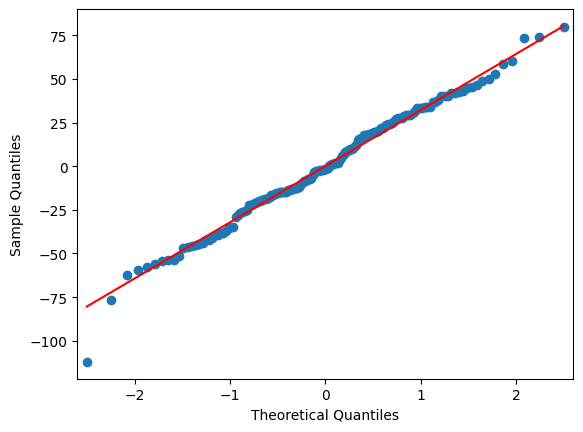

In [11]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson

fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

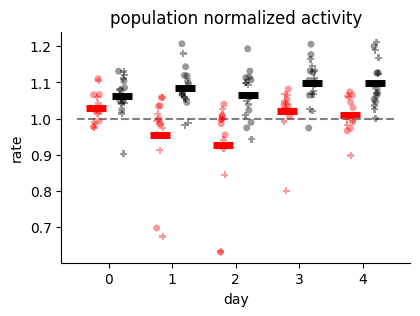

In [12]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=df.loc[df['ttype']=='familiar',:],
            x='day',
            y='rate',
            hue='condition', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            dodge=True,
            alpha=.4,
            ax=ax,
            legend=False)

sns.stripplot(data=df.loc[df['ttype']=='novel',:],
            x='day',
            y='rate',
            hue='condition', 
            hue_order=('ko', 'ctrl'), 
            palette=['red', 'black'],
            marker='P',
            dodge=True,
            alpha=.4,
            ax=ax,
            legend=False)

sns.pointplot(data=df.loc[df['ttype'].isin(('familiar','novel')),:],
            x='day',
            y='rate',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            hue_order = ['ko', 'ctrl'],
            dodge = .4,
            palette = ['red','black'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


#
ax.set_title('population normalized activity')
ax.hlines(1,-.5,4.5, color='gray', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figdir / 'novel_activity_rate_by_day.pdf', bbox_inches='tight')


In [13]:

res = pg.mixed_anova(data=df, dv='rate', 
                     within='day', between='condition', subject='mouse')
print(res)

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0    condition  0.170242    1   14  0.170242  20.399726  0.000484  0.593020   
1          day  0.040364    4   56  0.010091   2.566424  0.047922  0.154917   
2  Interaction  0.027968    4   56  0.006992   1.778298  0.146066  0.112705   

        eps  
0       NaN  
1  0.519895  
2       NaN  


In [14]:
block_rate_sparse = stx.novel_activity_rate.BlockTransitionActivityRate_Sparse(ts_key='F_dff')

SparseKO_02
SparseKO_06
SparseKO_08


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_10


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_11
SparseKO_13


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:305: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.

SparseKO_09


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:455: RuntimeWarning: Mean of empty slice
  comb = np.nanmean(np.concatenate((data['baseline_act'], data['block_act'])),axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:456: RuntimeWarning: Mean of empty slice
  fam = np.nanmean(data['block_fam_act'], axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:457: RuntimeWarning: Mean of empty slice
  nov = np.nanmean(data['block_nov_act'], axis=-1)/base.mean()


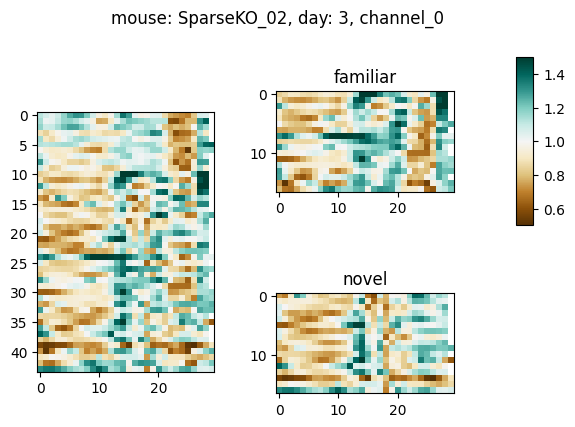

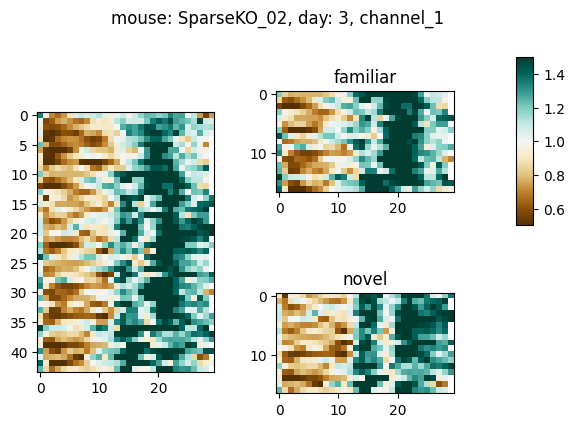

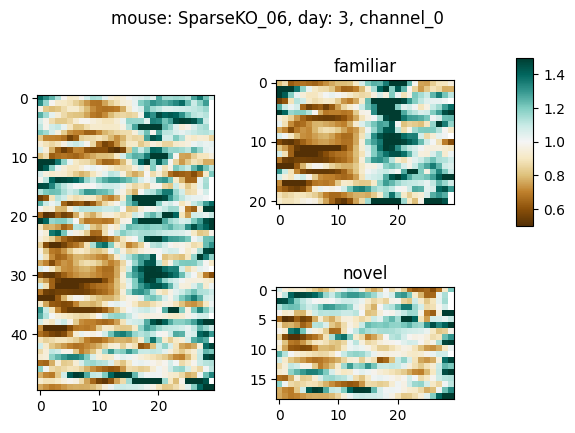

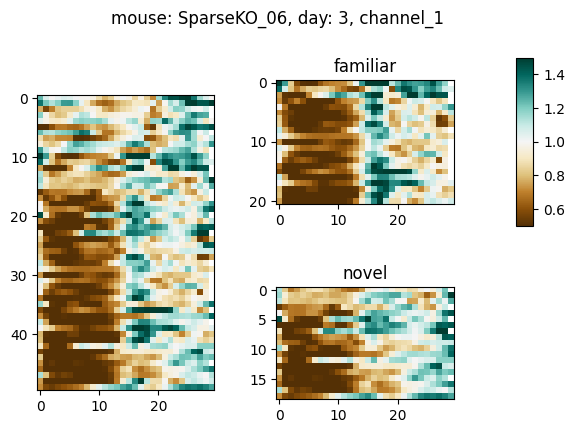

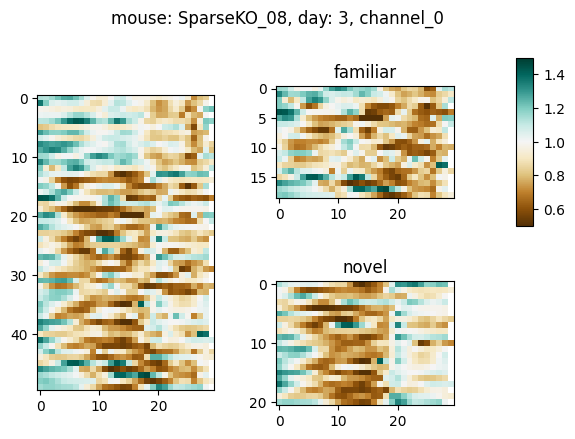

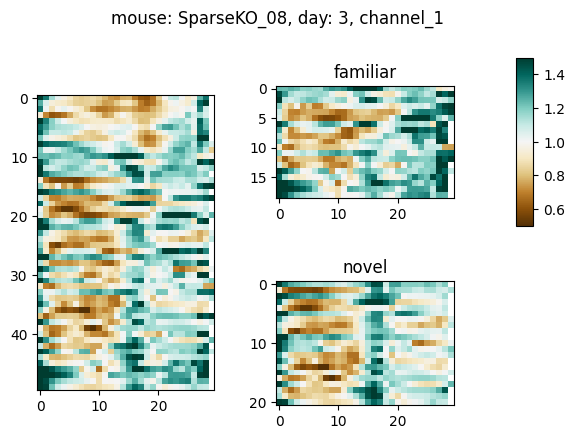

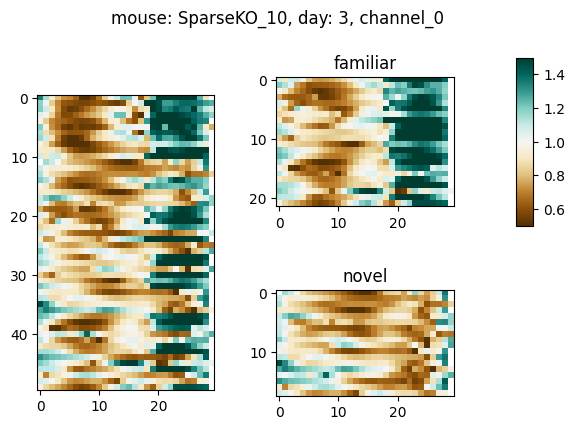

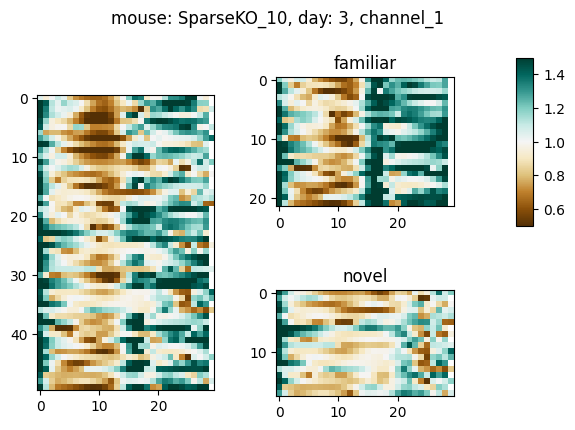

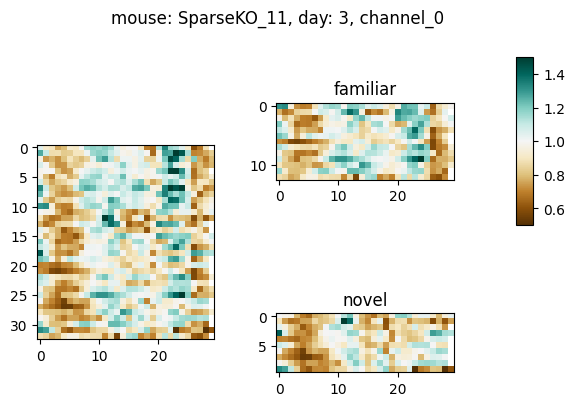

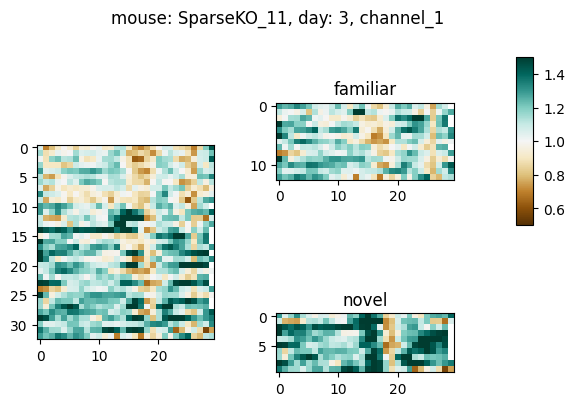

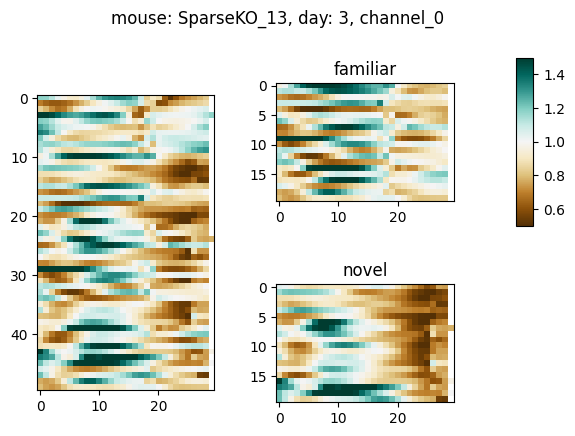

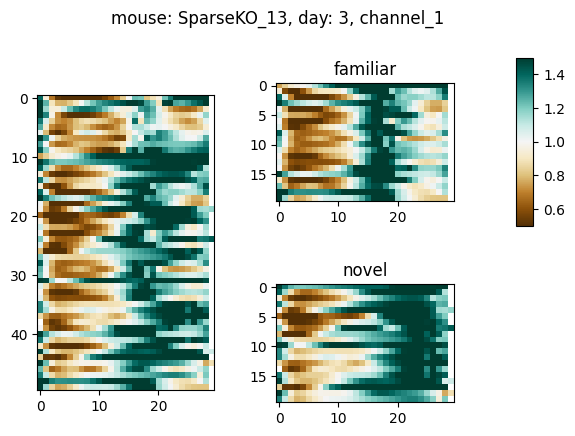

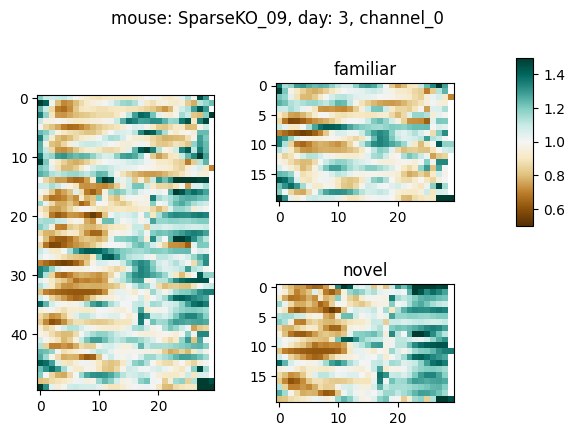

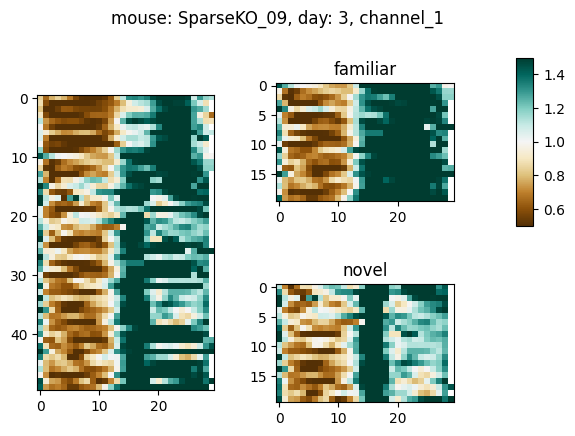

In [32]:
for mouse in sparse_mice:
    fig, ax = block_rate_sparse.plot_single_session( mouse, 3, 'channel_0', norm='population', cmap='BrBG', vmin=.5, vmax=1.5)
    fig.savefig(subdir / f'sparse_{mouse}_channel0_day3_activity_rate.pdf')
    fig, ax = block_rate_sparse.plot_single_session( mouse, 3, 'channel_1', norm='population', cmap='BrBG', vmin=.5, vmax=1.5)
    fig.savefig(subdir / f'sparse_{mouse}_channel1_day3_activity_rate.pdf')
    

In [16]:
def plot_block_avg_sparse(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
        fam = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}
        nov = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}

        for i, mouse in enumerate(sparse_mice):
            for chan in ('channel_0', 'channel_1'):
                if mouse == 'SparseKO_09' and day ==2:
                        continue
                
                data = block_rate_sparse.activity_rates[mouse][day][chan]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base
                    fam[chan][i,:_fam.shape[0]] = _fam
                    nov[chan][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base/_base.mean()
                    fam[chan][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[chan][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[chan][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[chan][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[chan][i,:_nov.shape[0]] = _nov

               

        for chan, color in zip(('channel_1','channel_0'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[chan], axis=0), sp.stats.sem(base[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[chan], axis=0), sp.stats.sem(fam[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[chan], axis=0), sp.stats.sem(nov[chan],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        
        a.set_xlabel('Trial')
    return fig, ax

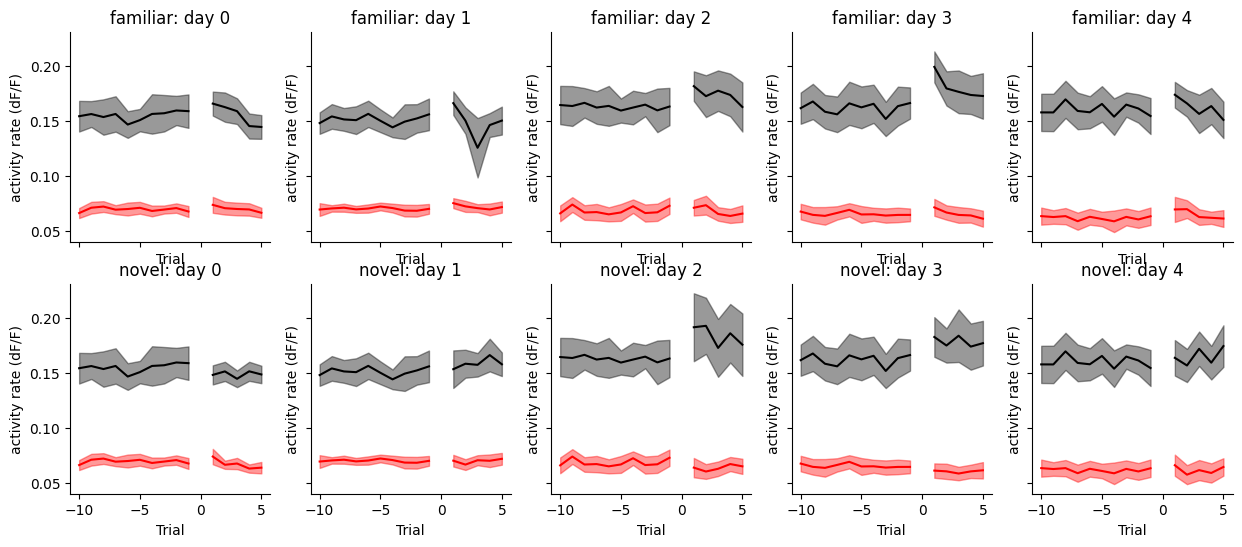

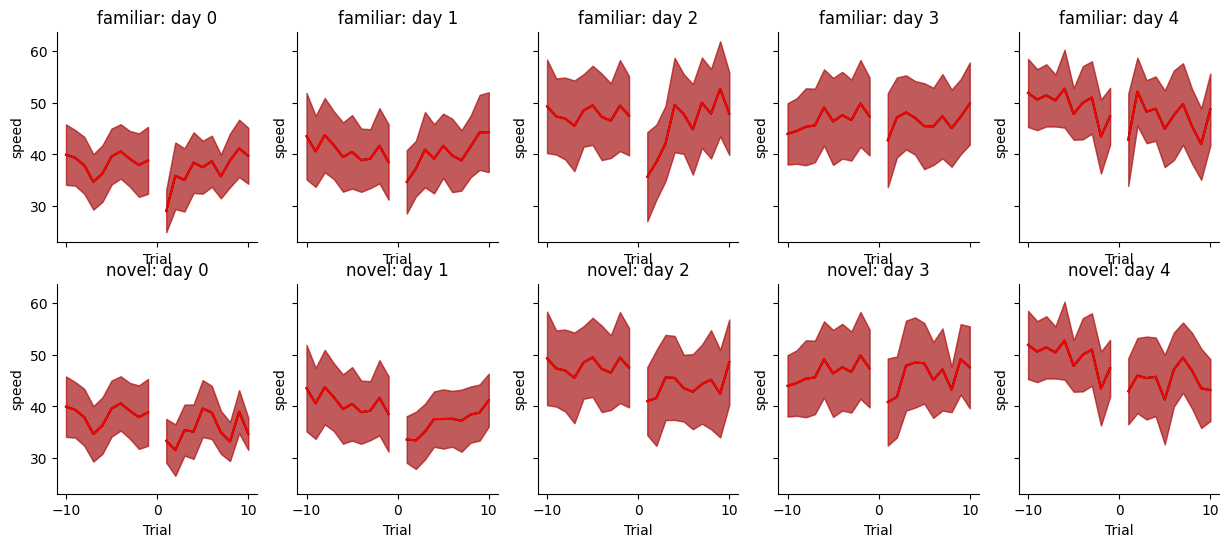

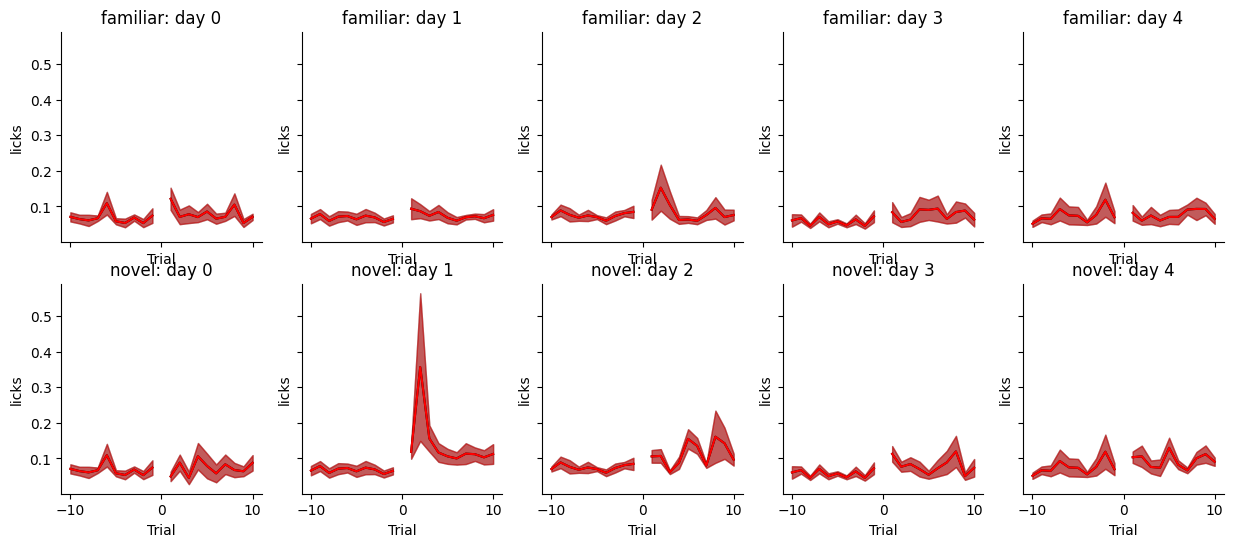

In [37]:
fig, ax = plot_block_avg_sparse(block_rate_sparse, norm = None, max_trial=5)
fig.savefig(figdir / 'last_block_sparse_activity_rate.pdf')
fig, ax = plot_block_avg_sparse(block_rate_sparse, key='speed', norm = None, max_trial=10)
fig, ax = plot_block_avg_sparse(block_rate_sparse, key='licks', norm = None, max_trial=10)

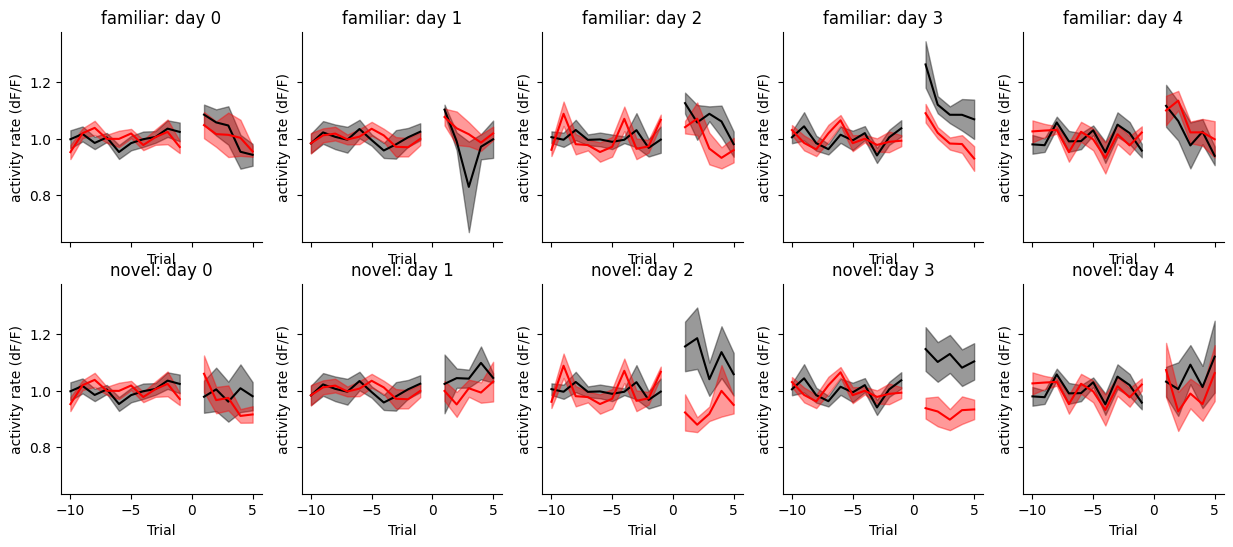

In [38]:
fig, ax = plot_block_avg_sparse(block_rate_sparse, norm ='population', max_trial=5)
fig.savefig(figdir / 'last_block_sparse_activity_rate_population_norm.pdf')

In [19]:
df = block_rate_sparse.build_dataframe(max_trial=5)
df = df.loc[df['day']<5]
df = df.loc[df['ttype'].isin(('familiar','novel')), :]  

In [27]:
df['channel'] = df['channel'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')
df['ttype'] = df['ttype'].astype('category')
df['rank_rate'] = df['rate'].rank()

mdl = smf.mixedlm("rank_rate ~ channel + ttype + day + licks + speed", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/tmp/ipykernel_193240/570027198.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['channel'] = df['channel'].astype('category')
/tmp/ipykernel_193240/570027198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['day'].astype('category')
/tmp/ipykernel_193240/570027198.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM   Dependent Variable:   rank_rate
No. Observations:     68        Method:               REML     
No. Groups:           7         Scale:                323.2394 
Min. group size:      8         Log-Likelihood:       -271.2808
Max. group size:      10        Converged:            Yes      
Mean group size:      9.7                                      
---------------------------------------------------------------
                     Coef.  Std.Err.   z   P>|z|  [0.025 0.975]
---------------------------------------------------------------
Intercept             1.115   19.656 0.057 0.955 -37.410 39.641
channel[T.channel_1] 11.412    4.361 2.617 0.009   2.865 19.958
day[T.1]              6.686    7.844 0.852 0.394  -8.688 22.059
day[T.2]              7.365    7.218 1.020 0.308  -6.783 21.513
day[T.3]              3.471    7.036 0.493 0.622 -10.318 17.261
day[T.4]              4.918    6.979 0.705 0.481  -8.761 18.596
licks                 3.318    3.305 1.004 0.315  -3.160  9.796
speed                19.856   18.513 1.073 0.283 -16.429 56.141
Group Var            60.960    3.221                           
===============================================================

"""

Shapiro-Wilk: W=0.947, p=0.00626
D'Agostino: χ²=12.267, p=0.00217


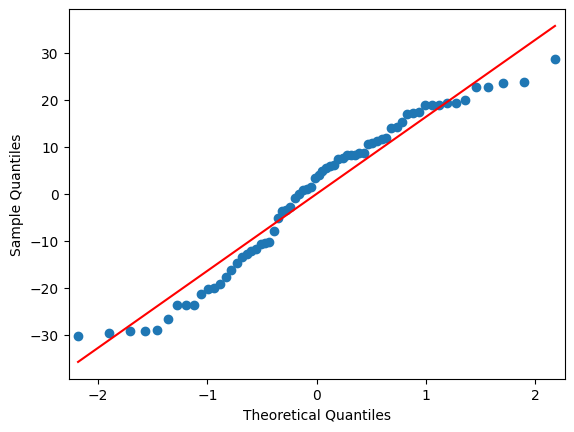

In [29]:
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

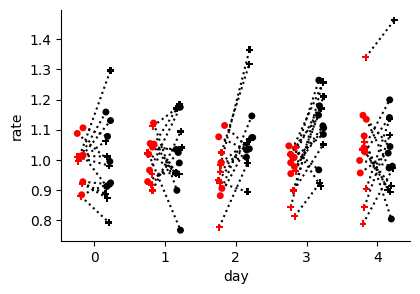

In [31]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype']=='familiar'),:]
sns.stripplot(data=df,
            x='day',
            y='rate',
            hue='channel', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)

df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype']=='novel'),:]

sns.stripplot(data=df,
            x='day',
            y='rate',
            hue='channel', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            marker='P',
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,20,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(figdir / 'sparse_last_block_activity_rate_by_day.pdf')


In [26]:
res = pg.rm_anova(data=df.loc[df['ttype']=='novel',:],
                  dv='rate', 
                  within=['channel','day'],subject='mouse')
print(res)

          Source        SS  ddof1  ddof2        MS         F     p-unc  \
0        channel  0.150637      1      5  0.150637  8.221915  0.035102   
1            day  0.038097      4     20  0.009524  0.412227  0.797740   
2  channel * day  0.070857      4     20  0.017714  1.726188  0.183754   

   p-GG-corr       ng2       eps  
0   0.035102  0.127179  1.000000  
1   0.634196  0.035542  0.403885  
2   0.220079  0.064144  0.575904  


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


In [161]:
df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype'].isin(('novel','familiar'))),:]
df['channel'] = df['channel'].astype('category')
df['day'] = df['day'].astype('category')
df['mouse'] = df['mouse'].astype('category')
df['ttype'] = df['ttype'].astype('category')
df['rank_rate'] = df['rate'].rank()

mdl = smf.mixedlm("rank_rate ~ channel + ttype + day  ", df, groups=df['mouse'])
res = mdl.fit()
res.summary()

/tmp/ipykernel_185757/1840399932.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['channel'] = df['channel'].astype('category')
/tmp/ipykernel_185757/1840399932.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['day'].astype('category')
/tmp/ipykernel_185757/1840399932.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:                MixedLM    Dependent Variable:    rank_rate
No. Observations:     136        Method:                REML     
No. Groups:           7          Scale:                 1414.7571
Min. group size:      16         Log-Likelihood:        -664.7204
Max. group size:      20         Converged:             Yes      
Mean group size:      19.4                                       
-----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------
Intercept             55.897    9.002  6.209 0.000  38.253 73.541
channel[T.channel_1]  17.294    6.451  2.681 0.007   4.651 29.937
ttype[T.novel]       -12.088    6.451 -1.874 0.061 -24.731  0.555
day[T.1]              10.321   10.053  1.027 0.305  -9.381 30.024
day[T.2]              11.583   10.511  1.102 0.270  -9.017 32.183
day[T.3]              15.714   10.053  1.563 0.118  -3.988 35.417
day[T.4]              12.964   10.053  1.290 0.197  -6.738 32.667
Group Var             67.966    2.190                            
=================================================================

"""

Shapiro-Wilk: W=0.983, p=0.0931
D'Agostino: χ²=5.853, p=0.0536


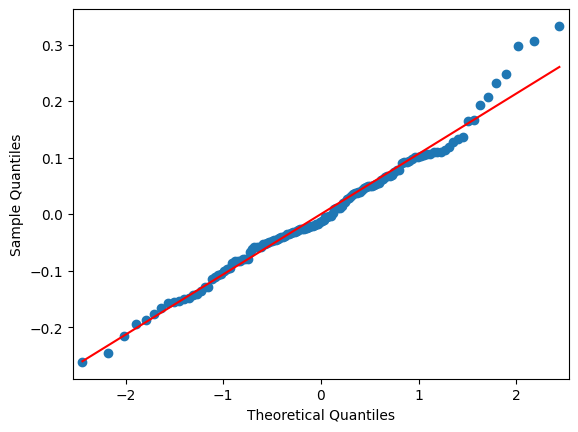

In [148]:
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")